## Mood classfication using CNN (HAPPY / SAD)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images

In [3]:
img = image.load_img(r'/content/drive/MyDrive/training/happy/portrait_1_1.png')

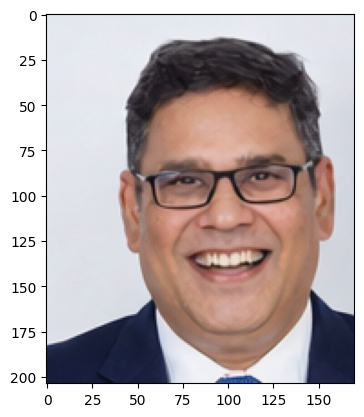

In [4]:
plt.imshow(img)

array([[[236, 229, 225],
        [238, 231, 228],
        [238, 230, 227],
        ...,
        [235, 228, 225],
        [236, 229, 226],
        [236, 228, 225]],

       [[238, 231, 227],
        [239, 231, 227],
        [240, 232, 228],
        ...,
        [235, 228, 225],
        [235, 228, 225],
        [236, 228, 224]],

       [[240, 233, 229],
        [239, 232, 228],
        [239, 232, 228],
        ...,
        [235, 228, 225],
        [236, 230, 227],
        [235, 227, 224]],

       ...,

       [[ 57,  28,  21],
        [ 58,  29,  22],
        [ 59,  29,  23],
        ...,
        [ 62,  32,  26],
        [ 60,  32,  26],
        [ 59,  30,  24]],

       [[ 59,  31,  24],
        [ 59,  29,  22],
        [ 58,  29,  22],
        ...,
        [ 66,  37,  31],
        [ 63,  35,  29],
        [ 58,  31,  25]],

       [[ 58,  28,  21],
        [ 58,  29,  22],
        [ 58,  29,  22],
        ...,
        [ 66,  36,  30],
        [ 65,  36,  30],
        [ 60,  34,  27]]], dtype=uint8)
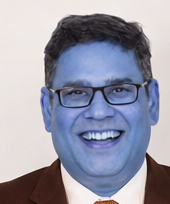

In [5]:
i1 = cv2.imread(r'/content/drive/MyDrive/training/happy/portrait_1_1.png')
i1
# 3 dimension metrics are created for the image
# the value ranges from 0-255

In [6]:
i1.shape
# shape of your image height, weight, rgb

(204, 170, 3)

In [8]:
train = ImageDataGenerator(rescale = 1/200)
validataion = ImageDataGenerator(rescale = 1/200)
# to scale all the images i need to divide with 255
# we need to resize the image using 200, 200 pixel

In [9]:
train_dataset = train.flow_from_directory(r'/content/drive/MyDrive/training',
                                         target_size = (200,200),
                                         batch_size = 3,
                                         class_mode = 'binary')
validataion_dataset = validataion.flow_from_directory(r'/content/drive/MyDrive/validation',
                                          target_size = (200,200),
                                          batch_size = 3,
                                          class_mode = 'binary')

Found 29 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [10]:
train_dataset.class_indices

{'happy': 0, 'not happy': 1}

In [11]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [12]:
# now we are applying maxpooling

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics = ['accuracy']
              )

In [15]:
model_fit = model.fit(train_dataset,epochs = 10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 788ms/step - accuracy: 0.6503 - loss: 0.9116
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7244 - loss: 0.5876
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9817 - loss: 0.1300
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0358
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0053
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 7.9132e-04
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 4.7244e-04
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 2.3201e-04
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 1.1701e-04


In [17]:
dir_path = r'/content/drive/MyDrive/testing'
for i in os.listdir(dir_path ):
    print(i)
    #img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
   # plt.imshow(img)
   # plt.show()

portrait_1_3.png
portrait_1_4.png
portrait_1_5.png
portrait_1_6.png
portrait_2_1.png
portrait_5_1.png
portrait_5_2.png
portrait_5_5.png
portrait_5_6.png


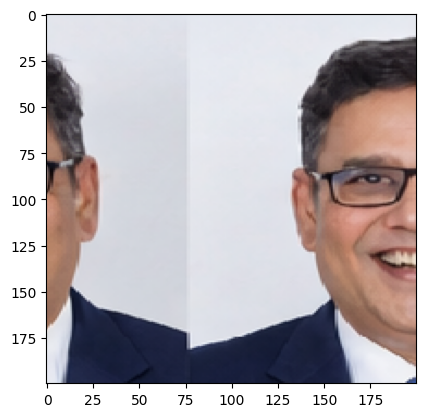

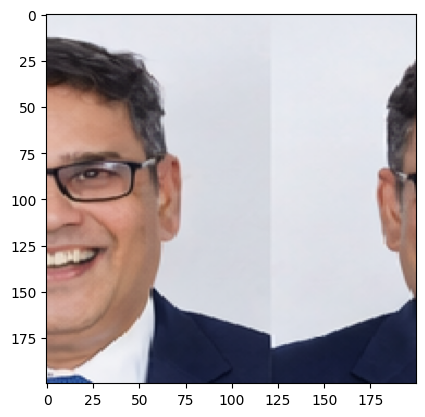

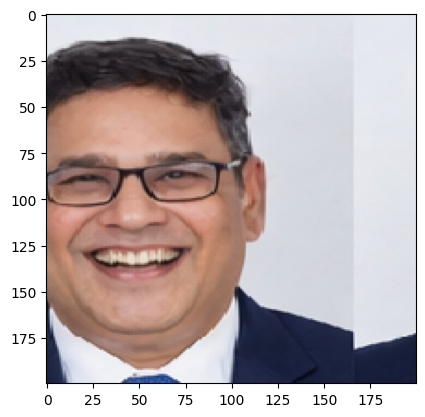

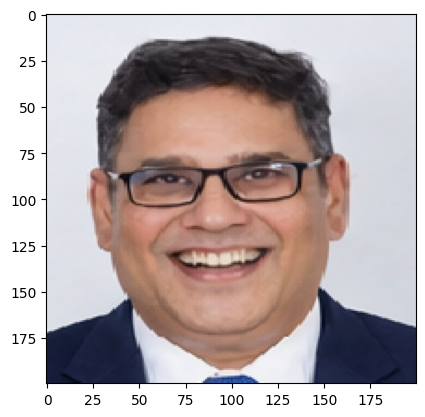

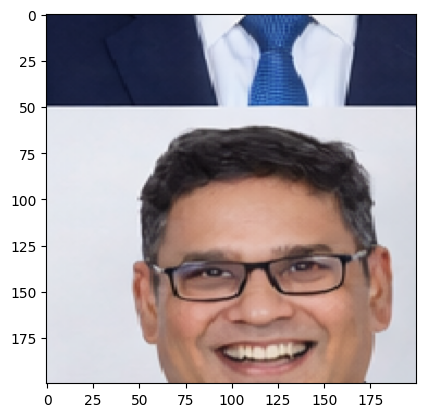

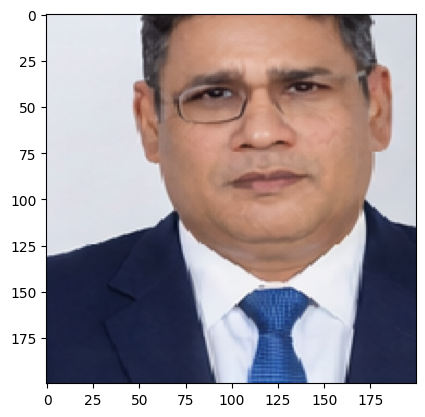

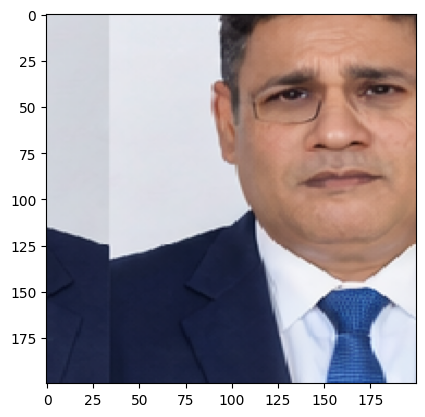

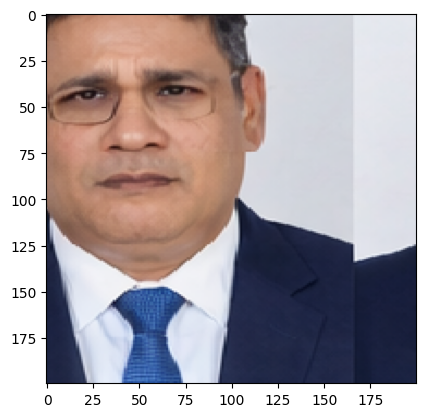

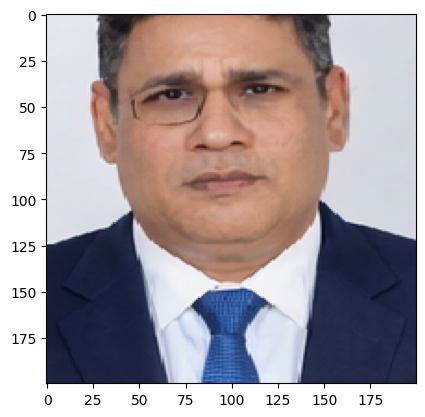

In [18]:
dir_path = r'/content/drive/MyDrive/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

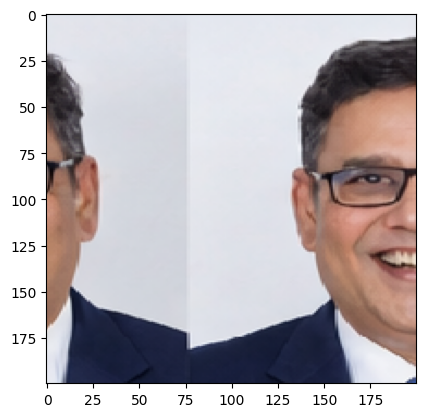

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
 i am not happy


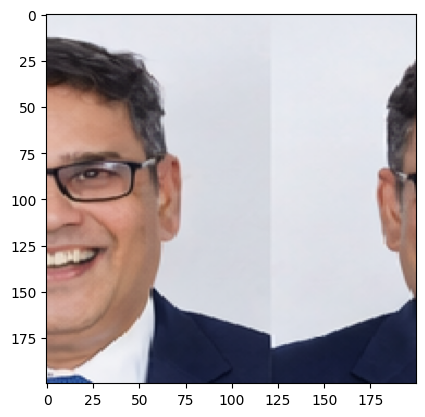

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
 i am not happy


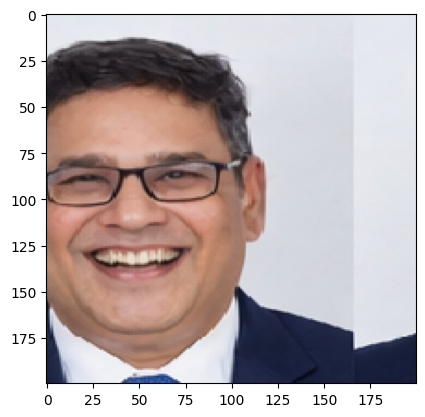

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 i am not happy


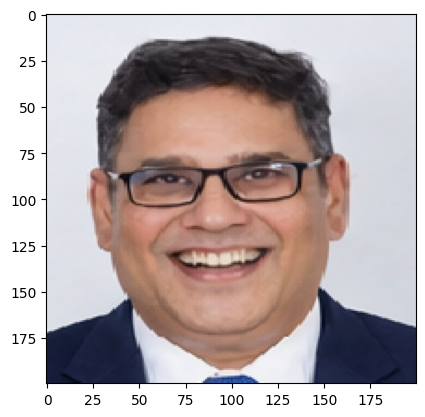

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 i am not happy


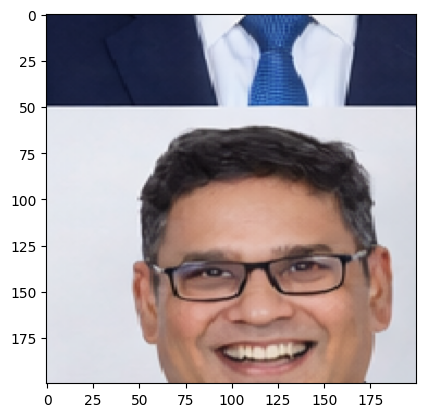

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
 i am not happy


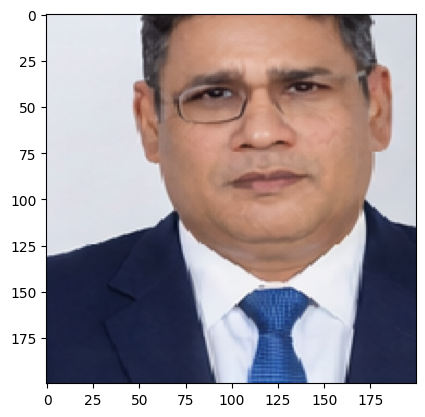

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i am happy


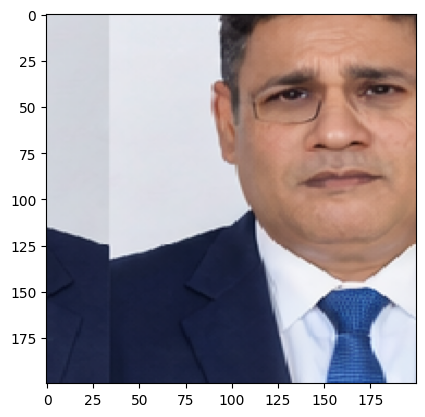

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
i am happy


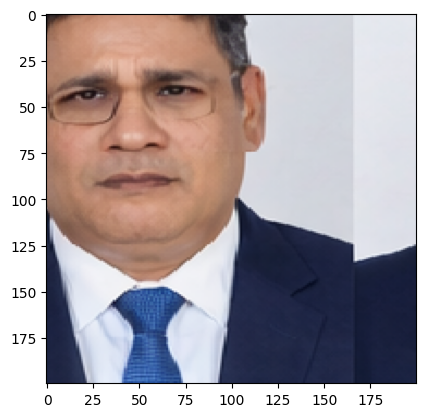

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
i am happy


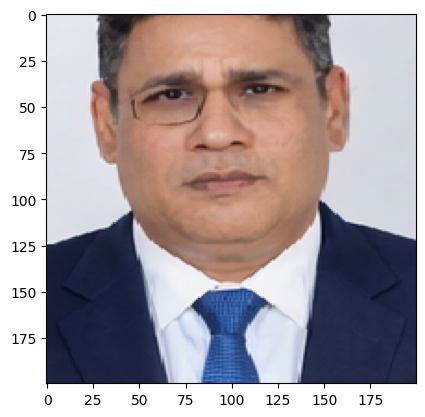

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
i am happy


In [19]:
dir_path = r'/content/drive/MyDrive/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print( ' i am not happy')
    else:
        print('i am happy')

In [22]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
  img=image.resize((200,200))
  x=np.array(img)
  x=np.expand_dims(x,axis=0)
  # X=X/200.0  # Corrected line: 'x' instead of 'X'
  x=x/200.0
  val=model.predict(x)
  if val <0.5:
    return 'Happy'
  else:
    return 'Not Happy'

iface=gr.Interface(fn=predict_mood,
                   inputs=gr.Image(type="pil",label="Upload an image"),
                   outputs=gr.Textbox(label="Prediction Mood"),
                   title="Mood Classification (Happy/Not Happy)",
                   description="Upload an image to classify if the person is happy or not happy."

)
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbf8310366c288a6b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
